In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\omar\Downloads\retail_store_inventory.csv")

In [3]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [4]:
df.shape

(73100, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [6]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
object_data = df.select_dtypes(include="object")

print("object columns:")
print(object_data.columns.tolist())
object_data.head()

object columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']


C:\Users\omar\AppData\Local\Temp\ipykernel_6484\569439884.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_data = df.select_dtypes(include="object")


,Date,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,Rainy,Autumn
1,2022-01-01,S001,P0002,Toys,South,Sunny,Autumn
2,2022-01-01,S001,P0003,Toys,West,Sunny,Summer
3,2022-01-01,S001,P0004,Toys,North,Cloudy,Autumn
4,2022-01-01,S001,P0005,Electronics,East,Sunny,Summer


In [9]:
numerical_data = df.select_dtypes(include="number")

print("numerical columns:")
print(numerical_data.columns.tolist())

numerical_data.head()


numerical columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']


,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
0,231,127,55,135.47,33.50,20,0,29.69
1,204,150,66,144.04,63.01,20,0,66.16
2,102,65,51,74.02,27.99,10,1,31.32
3,469,61,164,62.18,32.72,10,1,34.74
4,166,14,135,9.26,73.64,0,0,68.95


In [10]:
missing_raw=df.isna().sum().to_frame("missing_count")
missing_raw["missing_%"]=(df.isna().mean()*100).round(1)
missing_raw.sort_values("missing_%",ascending=False)

,missing_count,missing_%
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Demand Forecast,0,0.0
Price,0,0.0


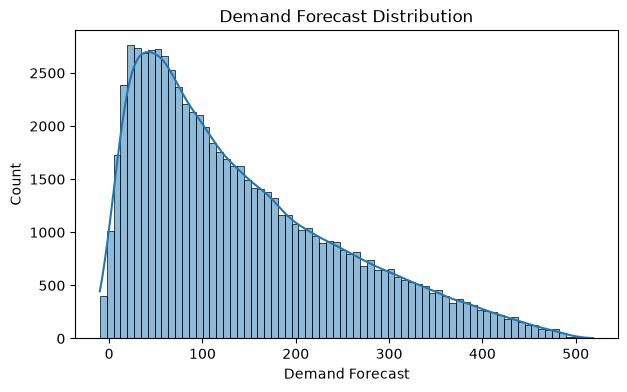

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df["Demand Forecast"], kde=True)
plt.title("Demand Forecast Distribution")
plt.show()

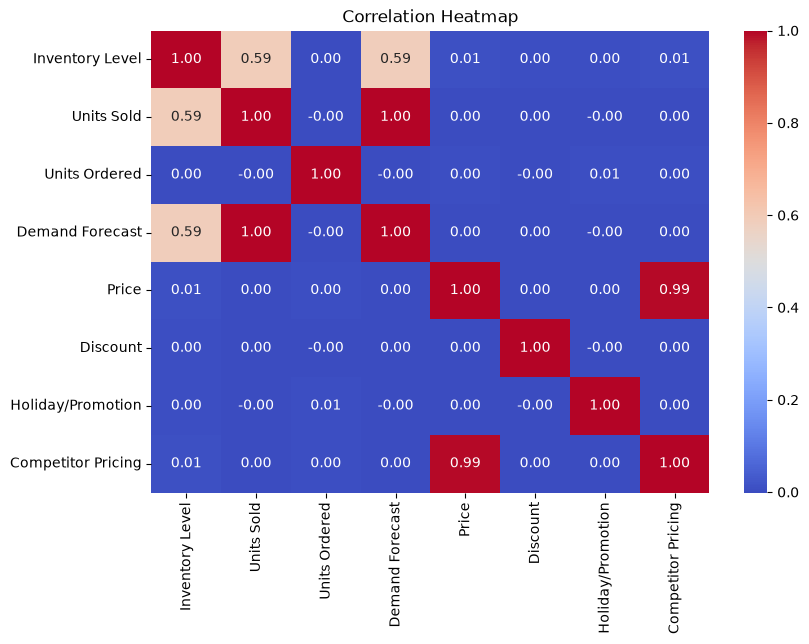

In [12]:
plt.figure(figsize=(9,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

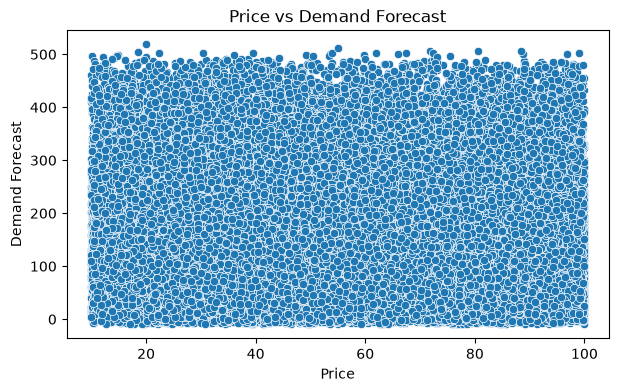

In [13]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df,
    x="Price",
    y="Demand Forecast"
)

plt.title("Price vs Demand Forecast")
plt.show()

In [14]:
x=df.drop(columns=["Demand Forecast"])
y=df["Demand Forecast"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
numeric_cols = X_train.select_dtypes(include=np.number).columns

for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [17]:
categorical_cols = X_train.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

In [18]:
print("Train missing:", X_train.isna().sum().sum())
print("Test missing:", X_test.isna().sum().sum())

Train missing: 0
Test missing: 0


In [19]:
for data in [X_train, X_test]:
    data["Date"] = pd.to_datetime(data["Date"])
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data["DayOfWeek"] = data["Date"].dt.dayofweek

X_train = X_train.drop(columns=["Date"])
X_test = X_test.drop(columns=["Date"])

In [20]:
categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()

print(categorical_cols)

['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']


In [21]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_encoded = encoder.fit_transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])

In [22]:
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

In [23]:
X_train = pd.concat(
    [X_train.drop(columns=categorical_cols), train_encoded],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=categorical_cols), test_encoded],
    axis=1
)

In [24]:
print("Train missing:", X_train.isna().sum().sum())
print("Test missing:", X_test.isna().sum().sum())

print("Non-numeric columns:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train missing: 0
Test missing: 0
Non-numeric columns:
[]
Train shape: (58480, 53)
Test shape: (14620, 53)


In [25]:
numeric_check_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Price"
]

for col in numeric_check_cols:
    data = X_train[col]

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((data < lower) | (data > upper)).sum()

    print(col, "Outliers:", outliers)

Inventory Level Outliers: 0
Units Sold Outliers: 567
Units Ordered Outliers: 0
Discount Outliers: 0
Holiday/Promotion Outliers: 0
Competitor Pricing Outliers: 0
Price Outliers: 0


In [26]:
from sklearn.preprocessing import StandardScaler
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)
print("Scaling completed successfully!")
print("X_train_scaled shape:", X_train_scaled.shape) 
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed successfully!
X_train_scaled shape: (58480, 53)
X_test_scaled shape: (14620, 53)


In [27]:
from sklearn.ensemble import RandomForestRegressor
#AI Demand Prediction Model
ai_model = RandomForestRegressor( n_estimators=200, random_state=42, n_jobs=-1 )
ai_model.fit(X_train_scaled, y_train)
print("AI Model trained successfully!")

AI Model trained successfully!


In [28]:
ai_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [29]:
y_pred = ai_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("AI Model Results")
print("----------------")
print("R2 Score :", round(r2, 4))
print("MAE      :", round(mae, 4))
print("RMSE     :", round(rmse, 4))

AI Model Results
----------------
R2 Score : 0.9935
MAE      : 7.5639
RMSE     : 8.8319


In [33]:
def ask_product(product_id):
    result = df[
       df["Product ID"].astype(str).str.lower()
       == str(product_id).lower()
]

    if result.empty:
      print("AI Assistant:")
      print("Product not found.")
      print("\nPlease enter a valid Product ID.")
      print("Example Product IDs:")
      print(df["Product ID"].astype(str).unique()[:10])
      return

    row = result.iloc[0].copy()

# Prepare product data for the AI model
    product_data = row.drop(labels=["Demand Forecast"]).to_frame().T

# Date features
    product_data["Date"] = pd.to_datetime(product_data["Date"])
    product_data["Year"] = product_data["Date"].dt.year
    product_data["Month"] = product_data["Date"].dt.month
    product_data["Day"] = product_data["Date"].dt.day
    product_data["DayOfWeek"] = product_data["Date"].dt.dayofweek

    product_data = product_data.drop(columns=["Date"])

# Categorical encoding
    product_encoded = encoder.transform(product_data[categorical_cols])

    product_encoded = pd.DataFrame(
    product_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=product_data.index
)

    product_data = pd.concat(
     [
        product_data.drop(columns=categorical_cols),
        product_encoded
     ],
    axis=1
)

# Make sure columns are in the same order as training data
    product_data = product_data.reindex(columns=X_train.columns, fill_value=0)

# Scaling
    product_scaled = scaler.transform(product_data)
# AI prediction
    predicted_demand = ai_model.predict(product_scaled)[0]
    print("\nAI Assistant")
    print("-------------------------")
    print(f"Product ID          : {row['Product ID']}")
    print(f"Actual Demand       : {row['Demand Forecast']:.2f}")
    print(f"AI Predicted Demand : {predicted_demand:.2f}")
    print(f"Inventory Level     : {row['Inventory Level']:.2f}")
    print(f"Units Sold          : {row['Units Sold']:.2f}")
    print(f"Units Ordered       : {row['Units Ordered']:.2f}")
    print(f"Price               : {row['Price']:.2f}")

    if row["Inventory Level"] < predicted_demand:
      print("Recommendation      : Consider restocking.")
    else:
       print("Recommendation      : Current inventory may be sufficient.")

In [34]:
product_id = input("Enter Product ID: ")
ask_product(product_id)


AI Assistant
-------------------------
Product ID          : P0020
Actual Demand       : 115.23
AI Predicted Demand : 110.69
Inventory Level     : 274.00
Units Sold          : 99.00
Units Ordered       : 166.00
Price               : 30.24
Recommendation      : Current inventory may be sufficient.
